In [1]:
# import kagglehub
# path = kagglehub.dataset_download("mrnize/pharmacy-transaction")

In [2]:
# from pathlib import Path
# files = [i for i in Path(path).rglob('*.csv')]
# files

In [76]:
# Prepare Data
import pandas as pd

# Visualize Data
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['axes.formatter.use_mathtext'] = True
plt.style.use('seaborn-v0_8-whitegrid')

In [77]:
def wrangle(filepath):
    # Read csv file into DataFrame
    df = pd.read_csv(filepath, parse_dates=['Transaction_Date'], index_col='Transaction_ID')

    # Drop high null column
    df.drop(columns=['Strength_mg'], inplace=True)

    # Rename Medicine Name to Brand Name
    df.rename(columns={'Medicine_Name': 'Brand_Name'}, inplace=True)

    # Return DataFrame
    return df

In [78]:
from pathlib import Path
import os
import sys

relative_path = 'Pharmacy_OLTP_SLStyle_18Months.csv'
try:
    base_path = sys._MEIPASS
except:
    base_path = os.path.abspath('.')
final_filename = Path(repr(os.path.join(base_path, relative_path)))


try:
    df = wrangle(final_filename)
except:
    try:
        final_filename = Path(r'C:/Users/Kenneth Owusu Boakye/.cache/kagglehub/datasets/mrnize/pharmacy-transaction/versions/1/Pharmacy_OLTP_SLStyle_18Months.csv')
        df = wrangle(final_filename)
    except:
        final_filename = 'https://raw.githubusercontent.com/Moxie882/data/refs/heads/master/datasets/mrnize/pharmacy-transaction/versions/1/Pharmacy_OLTP_SLStyle_18Months.csv'
        df = wrangle(final_filename)

In [80]:
# import itables
# itables.show(df.head())

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 1 to 50000
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Transaction_Date       50000 non-null  datetime64[us]
 1   Branch_ID              50000 non-null  int64         
 2   Branch_Name            50000 non-null  str           
 3   District               50000 non-null  str           
 4   Province               50000 non-null  str           
 5   Payment_Method         50000 non-null  str           
 6   Customer_Gender        50000 non-null  str           
 7   Customer_Age           50000 non-null  int64         
 8   Customer_City          50000 non-null  str           
 9   Medicine_ID            50000 non-null  int64         
 10  Brand_Name             50000 non-null  str           
 11  Generic_Name           50000 non-null  str           
 12  Medicine_Category      50000 non-null  str           
 13  Dosage_Form 

In [8]:
df.describe()

,Transaction_Date,Branch_ID,Customer_Age,Medicine_ID,Pack_Size,Quantity,Unit_Price_LKR,Discount_Rate,Line_Total_LKR,Year,Month
count,50000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000
mean,2022-09-30 02:25:10.848000,4.001940,48.915940,74.543920,35.769760,3.000780,1878.785603,0.074981,5205.639957,2022.331260,5.51626
min,2022-01-01 00:00:00,1.000000,18.000000,1.000000,10.000000,1.000000,26.240000,0.000000,29.340000,2022.000000,1.00000
25%,2022-05-17 00:00:00,2.000000,33.000000,37.000000,20.000000,2.000000,1031.060000,0.040000,2106.485000,2022.000000,3.00000
50%,2022-09-30 00:00:00,4.000000,49.000000,74.000000,28.000000,3.000000,1855.200000,0.070000,4154.685000,2022.000000,5.00000
75%,2023-02-13 00:00:00,6.000000,65.000000,112.000000,60.000000,4.000000,2755.572500,0.110000,7568.817500,2023.000000,8.00000
max,2023-06-30 00:00:00,7.000000,80.000000,148.000000,100.000000,5.000000,4499.410000,0.150000,21933.450000,2023.000000,12.00000
std,NaN,2.004319,18.159583,42.797969,28.103262,1.412112,1016.935615,0.043655,3960.828905,0.470671,3.30629


In [9]:
# Number of branches
def get_branch_count(df):
    return str(df['Branch_ID'].nunique())
get_branch_count(df)

'7'

In [10]:
# Best performing Branch (ID)
def get_best_branch(df, column='Branch_ID'):
    return df.groupby(column)['Line_Total_LKR'].sum().idxmax()
get_best_branch(df)

np.int64(1)

In [11]:
# Best performing Branch (Name)
get_best_branch(df, column='Branch_Name')

'Pharmacy - Colombo Fort'

In [12]:
# Worst performing Branch (ID)
def get_worst_branch(df, column='Branch_ID'):
    return df.groupby(column)['Line_Total_LKR'].sum().idxmin()
get_worst_branch(df)

np.int64(2)

In [13]:
# Worst performing Branch (Name)
get_worst_branch(df, column='Branch_Name')

'Pharmacy - Kandy City'

In [14]:
# Difference in performance between best and worst branches
def get_branch_perf_diff(df, column='Branch_ID'):
    branch_perf = df.groupby(column)['Line_Total_LKR'].sum().reset_index()
    return f'''{round(branch_perf['Line_Total_LKR'].max() - branch_perf['Line_Total_LKR'].min(), 2)} LKR'''
get_branch_perf_diff(df)

'2015233.26 LKR'

In [15]:
# Percentage of performance difference to best performance
def get_branch_perf_diff_perc(df, column='Branch_ID'):
    branch_perf = df.groupby(column)['Line_Total_LKR'].sum().reset_index()
    return f'''{round((branch_perf['Line_Total_LKR'].max() - branch_perf['Line_Total_LKR'].min()) / branch_perf['Line_Total_LKR'].max() * 100, 2)}%'''
get_branch_perf_diff_perc(df)

'5.3%'

In [16]:
# Most common payment method
def get_most_common_payment(df):
    return df['Payment_Method'].value_counts().head(1).keys()[0]
get_most_common_payment(df[df['Branch_ID'] == 7])

'Cash'

In [17]:
# Rarest payment method
def get_rarest_payment(df):
    return df['Payment_Method'].value_counts().tail(1).keys()[0]
get_rarest_payment(df[df['Branch_ID'] == 7])

'Insurance'

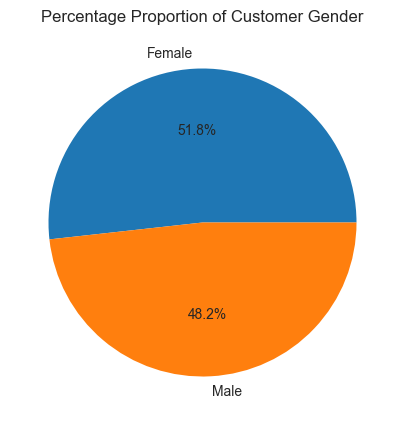

In [18]:
# Proportion of customers by gender
# df_branch = df[df['Branch_ID'] == 5]
def get_gender_prop(df):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    ax.pie(
        (
            round(df['Customer_Gender']
                .value_counts(normalize=True)
                .mul(100), 2)),
        labels=['Female', 'Male'],
        autopct='%1.1f%%'
    )
    ax.set_title('Percentage Proportion of Customer Gender')
    plt.close()
    return fig
get_gender_prop(df)

In [19]:
# Most Popular Product amongst Females (Generic)
def get_most_popular_product(df, column='Generic_Name', gender='Female'):
    return df[df['Customer_Gender'] == gender][column].value_counts().head(1).keys()[0]
get_most_popular_product(df)

'Losartan'

In [20]:
# Most Popular Product amongst Females (Brand)
# def get_most_popular_brand_female(df, column='Brand_Name'):
#     return df[df['Customer_Gender'] == 'Female'][column].value_counts().head(1).keys()[0]
get_most_popular_product(df, column='Brand_Name')

'Omep Amoxicillin + Clavulanate Cream 15g'

In [21]:
# Most Popular Product amongst Males (Generic)
# def get_most_popular_male(df, column='Generic_Name'):
#     return df[df['Customer_Gender'] == 'Male'][column].value_counts().head(1).keys()[0]
get_most_popular_product(df, gender='Male')

'Domperidone'

In [22]:
# Most Popular Product amongst Males (Brand)
# def get_most_popular_brand_male(df, column='Brand_Name'):
#     return df[df['Customer_Gender'] == 'Male'][column].value_counts().head(1).keys()[0]
get_most_popular_product(df, column='Brand_Name', gender='Male')

'Aller Paracetamol Inhaler'

In [23]:
# Least Popular Product amongst Females (Generic)
def get_least_popular_product(df, column='Generic_Name', gender='Female'):
    return df[df['Customer_Gender'] == gender][column].value_counts().tail(1).keys()[0]
get_least_popular_product(df)

'Vitamin D3'

In [24]:
# Least Popular Product amongst Females (Brand)
# def get_least_popular_brand_female(df, column='Brand_Name'):
#     return df[df['Customer_Gender'] == 'Female'][column].value_counts().tail(1).keys()[0]
get_least_popular_product(df, column='Brand_Name')

'Calpol Vitamin D3 200mg Tablet'

In [25]:
# Least Popular Product amongst Males (Generic)
# def get_least_popular_male(df, column='Generic_Name'):
#     return df[df['Customer_Gender'] == 'Male'][column].value_counts().tail(1).keys()[0]
get_least_popular_product(df, gender='Male')

'Budesonide'

In [26]:
# Least Popular Product amongst Males (Brand)
# def get_least_popular_brand_male(df, column='Brand_Name'):
#     return df[df['Customer_Gender'] == 'Male'][column].value_counts().tail(1).keys()[0]
get_least_popular_product(df, column='Brand_Name', gender='Male')

'Cipro Phenylephrine 650mg Capsule'

In [27]:
# Age Range of Customers
def get_age_range(df, column='Customer_Age'):
    return f'''Customer Age ranges from "{df[column].min()}" to "{df[column].max()}" years old.'''
get_age_range(df)

'Customer Age ranges from "18" to "80" years old.'

In [28]:
# Most Popular Product per Age (Generic)
def get_most_popular_age(df, column='Generic_Name'):
    return (df.groupby('Customer_Age')[column]
        .value_counts()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .groupby('Customer_Age')
        .head(1)[['Customer_Age', column]]
        .sort_values('Customer_Age')
        )
get_most_popular_age(df)

,Customer_Age,Generic_Name
0,18,Gliclazide
44,19,Amoxicillin
88,20,Amoxicillin
132,21,Chlorhexidine
176,22,Amoxicillin
...,...,...
2552,76,Domperidone
2596,77,Chlorhexidine
2640,78,Prednisolone
2684,79,Diclofenac


In [29]:
# Least Popular Drugs by Age of Customer (Generic)
def get_least_popular_age(df, column='Generic_Name'):
    return (df.groupby('Customer_Age')[column]
        .value_counts()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
        .groupby('Customer_Age')
        .tail(1)[['Customer_Age', column]]
        .sort_values('Customer_Age')
           )
get_least_popular_age(df)

,Customer_Age,Generic_Name
43,18,Budesonide
87,19,Salbutamol
131,20,Doxycycline
175,21,Cetirizine
219,22,Azithromycin
...,...,...
2595,76,Vitamin D3
2639,77,Guaifenesin
2683,78,Budesonide
2727,79,Budesonide


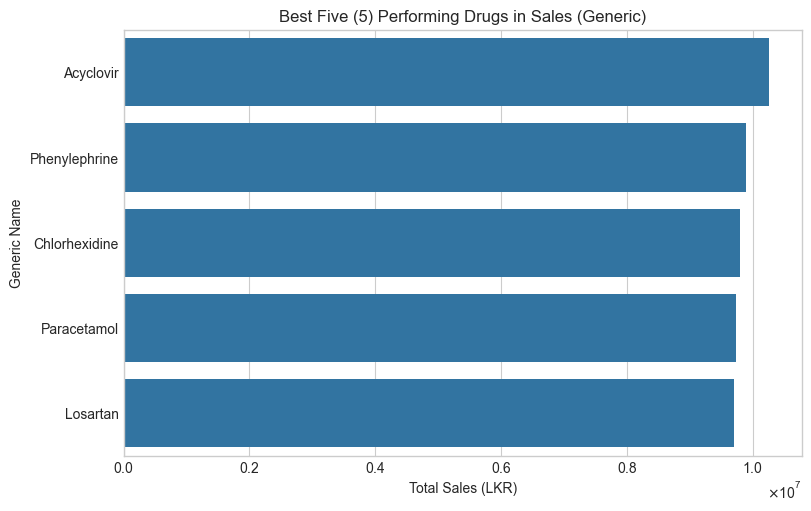

In [30]:
# Best performing drugs (Generic)
def get_best_drugs(df, column='Generic_Name'):
    fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
    sns.barplot(
        (df.groupby(column)['Line_Total_LKR']
        .sum()
        .sort_values(ascending=False)
        .head(5)
           ),
                orient='h', 
                ax=ax)
    ax.set_ylabel(' '.join(column.split('_')))
    ax.set_xlabel('Total Sales (LKR)')
    ax.set_title(f'''Best Five (5) Performing Drugs in Sales ({column.split('_')[0]})''')
    plt.close()
    return fig
get_best_drugs(df)

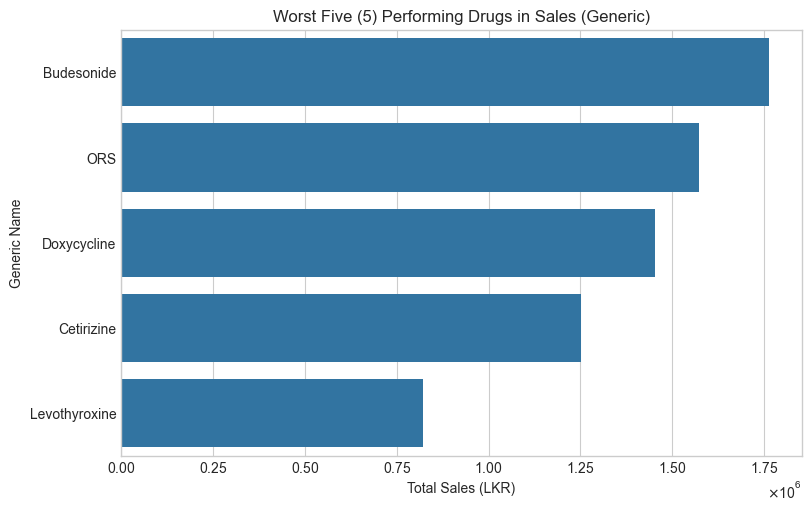

In [31]:
# Worst performing drugs (Generic)
def get_worst_drugs(df, column='Generic_Name'):
    fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
    sns.barplot(
        (df.groupby(column)['Line_Total_LKR']
        .sum()
        .sort_values(ascending=False)
        .tail(5)
           ),
                orient='h', 
                ax=ax)
    ax.set_ylabel(' '.join(column.split('_')))
    ax.set_xlabel('Total Sales (LKR)')
    ax.set_title(f'''Worst Five (5) Performing Drugs in Sales ({column.split('_')[0]})''')
    plt.close()
    return fig
get_worst_drugs(df)

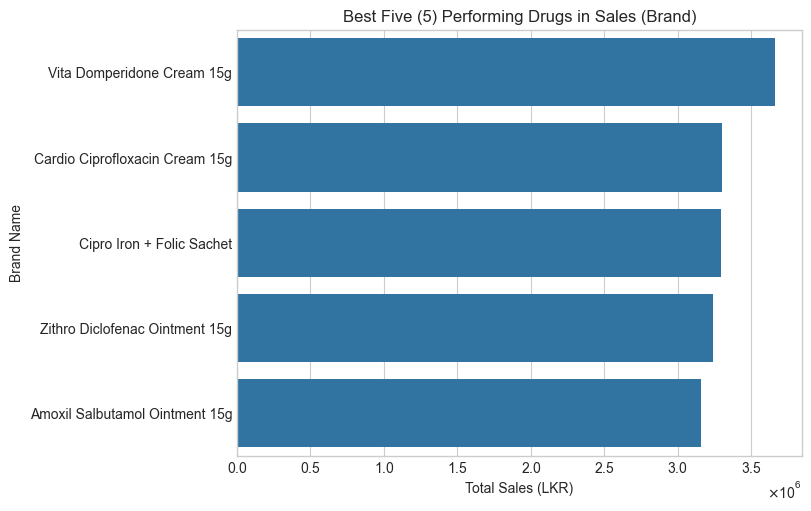

In [32]:
# Best performing drugs (Brand)
# def get_best_drugs_brand(df, column='Brand_Name'):
#     return df.groupby(column)['Line_Total_LKR'].sum().sort_values(ascending=False).head(5)
get_best_drugs(df, column='Brand_Name')

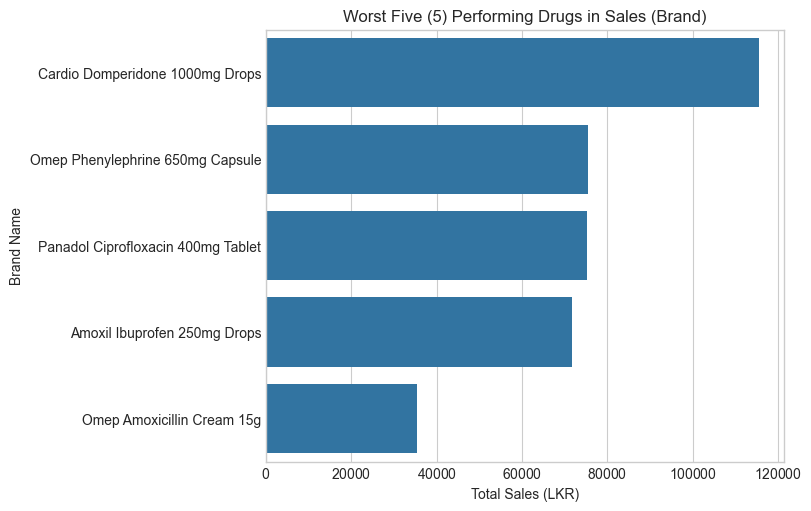

In [33]:
# Worst performing drugs (Brand)
# def get_worst_drugs_brand(df, column='Brand_Name'):
#     return df.groupby(column)['Line_Total_LKR'].sum().sort_values(ascending=False).tail(5)
get_worst_drugs(df, column='Brand_Name')

In [34]:
df.groupby('Dosage_Form')['Quantity'].sum().index.tolist()

['Capsule',
 'Cream',
 'Drops',
 'Inhaler',
 'Ointment',
 'Sachet',
 'Syrup',
 'Tablet']

In [35]:
df['Dosage_Form'].value_counts().index.tolist()

['Capsule',
 'Cream',
 'Sachet',
 'Inhaler',
 'Ointment',
 'Tablet',
 'Syrup',
 'Drops']

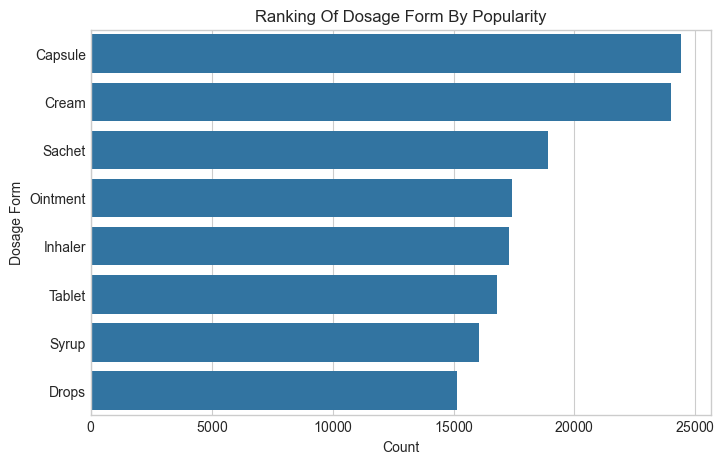

In [36]:
# Ranking of Dosage forms
def get_dosage_form_rank(df):
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        (df.groupby('Dosage_Form')['Quantity']
            .sum()
            .sort_values(ascending=False)
        ),
        orient='h', 
        ax=ax
    )
    ax.set_ylabel('Dosage Form')
    ax.set_xlabel('Count')
    ax.set_title('Ranking Of Dosage Form By Popularity')
    plt.close()
    return fig
get_dosage_form_rank(df)

In [37]:
# Most Popular Dosage Form
def get_most_popular_dosage_form(df):
    return df.groupby('Dosage_Form')['Quantity'].sum().sort_values().tail(1).index[0]
get_most_popular_dosage_form(df)

'Capsule'

In [38]:
# Least Popular Dosage Form
def get_least_popular_dosage_form(df):
    return df.groupby('Dosage_Form')['Quantity'].sum().sort_values().head(1).index[0]
get_least_popular_dosage_form(df)

'Drops'

In [39]:
# List the Suppliers
def get_supplier_list(df):
    return pd.DataFrame({'Supplier List': df['Supplier_Name'].unique()})
get_supplier_list(df)

,Supplier List
0,Ceylon Pharma Traders
1,Astron Pharma Supply
2,Softlogic Pharma Distribution
3,Union Chemists Supply
4,SPC Distribution (LK)
5,Ceyoka Healthcare Supply
6,Healthguard Central Supply
7,Hemas Pharma Wholesale


In [40]:
# Supplier for most drugs
def get_most_popular_supplier(df):
    return df.groupby('Supplier_Name')['Supplier_Name'].count().sort_values(ascending=False).head(1).index[0]
get_most_popular_supplier(df)

'Ceyoka Healthcare Supply'

In [41]:
# Supplier for least drugs
def get_least_popular_supplier(df):
    return df.groupby('Supplier_Name')['Supplier_Name'].count().sort_values(ascending=False).tail(1).index[0]
get_least_popular_supplier(df)

'SPC Distribution (LK)'

In [42]:
# # Best Discount (Generic)
# df.groupby('Generic_Name')['Discount_Rate'].max().sort_values(ascending=False).head(2)

In [43]:
# Best Discount
def get_best_discount(df, column='Discount_Rate'):
    return f'''{df[column].max() * (100)}%'''
get_best_discount(df)

'15.0%'

In [44]:
# The List of Available Discount Rates
def get_discount_rate_list(df, column='Discount_Rate'):
    return df[column].unique().tolist()
get_discount_rate_list(df)

[0.12,
 0.05,
 0.08,
 0.13,
 0.06,
 0.1,
 0.0,
 0.15,
 0.01,
 0.07,
 0.04,
 0.09,
 0.03,
 0.11,
 0.02,
 0.14]

In [45]:
# This is irrelavant since discount given is not tied to the specific drug.
# Number of Drugs with Best Discount (Generic)
mask = df['Discount_Rate'] == df['Discount_Rate'].max()
df[mask]['Generic_Name'].nunique()

44

In [46]:
df[mask].head()

,Transaction_Date,Branch_ID,Branch_Name,District,Province,Payment_Method,Customer_Gender,Customer_Age,Customer_City,Medicine_ID,...,Supplier_Name,Prescription_Required,Batch_No,Expiry_Date,Quantity,Unit_Price_LKR,Discount_Rate,Line_Total_LKR,Year,Month
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
11,2022-07-02,7,Pharmacy - Ratnapura,Ratnapura,Sabaragamuwa,Insurance,Female,30,Negombo,46,...,Healthguard Central Supply,Yes,LK8263-67,2/22/2024,4,3317.65,0.15,11280.01,2022,7
12,2022-03-31,3,Pharmacy - Galle,Galle,Southern,Cash,Female,41,Jaffna,126,...,Ceylon Pharma Traders,Yes,LK2565-25,12/21/2023,2,2041.14,0.15,3469.94,2022,3
23,2023-02-23,4,Pharmacy - Kurunegala,Kurunegala,North Western,Card,Female,33,Ratnapura,71,...,Union Chemists Supply,No,LK6610-29,8/16/2024,2,1310.23,0.15,2227.39,2023,2
77,2023-03-02,2,Pharmacy - Kandy City,Kandy,Central,Card,Female,75,Colombo,133,...,Softlogic Pharma Distribution,Yes,LK8881-23,12/27/2023,3,3419.69,0.15,8720.21,2023,3
162,2022-06-05,5,Pharmacy - Negombo,Gampaha,Western,Cash,Male,50,Colombo,44,...,Hemas Pharma Wholesale,Yes,LK4484-35,5/1/2023,3,1346.53,0.15,3433.65,2022,6


In [47]:
df.columns

Index(['Transaction_Date', 'Branch_ID', 'Branch_Name', 'District', 'Province',
       'Payment_Method', 'Customer_Gender', 'Customer_Age', 'Customer_City',
       'Medicine_ID', 'Brand_Name', 'Generic_Name', 'Medicine_Category',
       'Dosage_Form', 'Pack_Size', 'Supplier_Name', 'Prescription_Required',
       'Batch_No', 'Expiry_Date', 'Quantity', 'Unit_Price_LKR',
       'Discount_Rate', 'Line_Total_LKR', 'Year', 'Month'],
      dtype='str')

In [48]:
# Worst Discount
def get_worst_discount(df, column='Discount_Rate'):
    return f'''{df[column].min()}%'''
get_worst_discount(df)

'0.0%'

In [49]:
yearly = df.set_index('Transaction_Date').resample('YE')['Line_Total_LKR'].sum()
yearly

Transaction_Date
2022-12-31    1.704192e+08
2023-12-31    8.986282e+07
Freq: YE-DEC, Name: Line_Total_LKR, dtype: float64

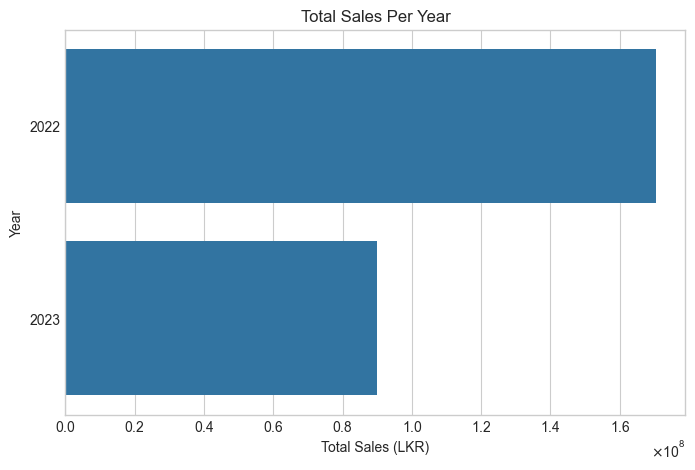

In [65]:
# Resample the dataframe by year And Calculate the total Drug Sales
def get_yearly_sales(df):
    yearly_df = yearly = df.set_index('Transaction_Date').resample('YE')['Line_Total_LKR'].sum()
    yearly_df.index = yearly_df.index.year
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(
        yearly_df,
        orient='h',
        ax=ax
    )
    ax.set_xlabel('Total Sales (LKR)')
    ax.set_ylabel('Year')
    ax.set_title('Total Sales Per Year')
    plt.close()
    return fig
get_yearly_sales(df)

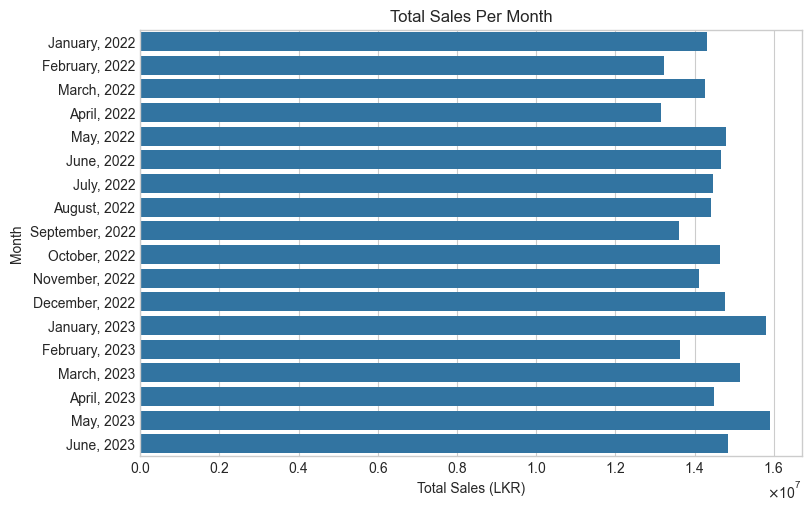

In [70]:
# Resample the dataframe by month And Calculate the total Drug Sales
def get_monthly_sales(df):
    monthly_df = df.set_index('Transaction_Date').sort_index().resample('ME')['Line_Total_LKR'].sum()
    monthly_df.index = [f"{i.month_name()}, {i.year}" for i in monthly_df.index]
    fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
    sns.barplot(
        monthly_df,
        orient='h',
        ax=ax
    )
    ax.set_xlabel('Total Sales (LKR)')
    ax.set_ylabel('Month')
    ax.set_title('Total Sales Per Month')
    plt.close()
    return fig
get_monthly_sales(df)

In [52]:
# Most Expensive Drug
def get_most_expensive_drug(df, column='Generic_Name'):
    return df.groupby(column)['Unit_Price_LKR'].max().sort_values().tail(1).index[0]
get_most_expensive_drug(df)

'Domperidone'

In [53]:
# Looking at specified column to confirm
df.loc[df['Unit_Price_LKR'].idxmax()]

Transaction_Date                   2022-11-06 00:00:00
Branch_ID                                            5
Branch_Name                         Pharmacy - Negombo
District                                       Gampaha
Province                                       Western
Payment_Method                                    Cash
Customer_Gender                                   Male
Customer_Age                                        43
Customer_City                                  Negombo
Medicine_ID                                         73
Brand_Name                  Vita Domperidone Cream 15g
Generic_Name                               Domperidone
Medicine_Category                               Gastro
Dosage_Form                                      Cream
Pack_Size                                           28
Supplier_Name            Softlogic Pharma Distribution
Prescription_Required                               No
Batch_No                                     LK5443-67
Expiry_Dat

In [54]:
# Since Acyclovir is the best performing product in Sales, I have to confirm the Price
df[df['Generic_Name'] == 'Acyclovir'].head()

,Transaction_Date,Branch_ID,Branch_Name,District,Province,Payment_Method,Customer_Gender,Customer_Age,Customer_City,Medicine_ID,...,Supplier_Name,Prescription_Required,Batch_No,Expiry_Date,Quantity,Unit_Price_LKR,Discount_Rate,Line_Total_LKR,Year,Month
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
12,2022-03-31,3,Pharmacy - Galle,Galle,Southern,Cash,Female,41,Jaffna,126,...,Ceylon Pharma Traders,Yes,LK2565-25,12/21/2023,2,2041.14,0.15,3469.94,2022,3
25,2022-07-14,5,Pharmacy - Negombo,Gampaha,Western,Insurance,Female,49,Jaffna,126,...,Ceylon Pharma Traders,Yes,LK5727-96,8/8/2023,1,2085.17,0.06,1960.06,2022,7
62,2022-07-12,6,Pharmacy - Jaffna,Jaffna,Northern,Card,Male,67,Matara,125,...,Ceyoka Healthcare Supply,Yes,LK5799-67,1/8/2023,4,2999.38,0.05,11397.64,2022,7
88,2022-03-02,4,Pharmacy - Kurunegala,Kurunegala,North Western,Card,Female,58,Jaffna,125,...,Ceyoka Healthcare Supply,Yes,LK9344-93,2/20/2024,5,2605.58,0.09,11855.39,2022,3
97,2022-03-05,4,Pharmacy - Kurunegala,Kurunegala,North Western,Cash,Female,20,Negombo,126,...,Ceylon Pharma Traders,Yes,LK5550-51,3/30/2023,3,2459.75,0.12,6493.74,2022,3


In [55]:
# Least Expensive Drug
def get_least_expensive_drug(df, column='Generic_Name'):
    return df.groupby(column)['Unit_Price_LKR'].min().sort_values(ascending=False).tail(1).index[0]
get_least_expensive_drug(df)
# df['Generic_Name'][df['Unit_Price_LKR'] == df['Unit_Price_LKR'].min()]

'Amoxicillin'

In [56]:
# Confirming
df.loc[df['Unit_Price_LKR'].idxmin()]

Transaction_Date                   2022-03-24 00:00:00
Branch_ID                                            2
Branch_Name                      Pharmacy - Kandy City
District                                         Kandy
Province                                       Central
Payment_Method                                    Cash
Customer_Gender                                 Female
Customer_Age                                        25
Customer_City                                   Matara
Medicine_ID                                         18
Brand_Name                  Omep Amoxicillin Cream 15g
Generic_Name                               Amoxicillin
Medicine_Category                           Antibiotic
Dosage_Form                                      Cream
Pack_Size                                           60
Supplier_Name            Softlogic Pharma Distribution
Prescription_Required                              Yes
Batch_No                                     LK2143-27
Expiry_Dat

In [67]:
# Single Most Expensive Transaction
def get_most_expensive_transaction(df):
    return df.loc[[df['Line_Total_LKR'].idxmax()]]
get_most_expensive_transaction(df)

,Transaction_Date,Branch_ID,Branch_Name,District,Province,Payment_Method,Customer_Gender,Customer_Age,Customer_City,Medicine_ID,...,Supplier_Name,Prescription_Required,Batch_No,Expiry_Date,Quantity,Unit_Price_LKR,Discount_Rate,Line_Total_LKR,Year,Month
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
3170,2023-05-30,1,Pharmacy - Colombo Fort,Colombo,Western,Card,Male,36,Jaffna,78,...,Ceylon Pharma Traders,No,LK7082-54,11/26/2023,5,4386.69,0.0,21933.45,2023,5


In [68]:
# Least Expensive Transaction
def get_least_expensive_transaction(df):
    return df.loc[[df['Line_Total_LKR'].idxmin()]]
get_least_expensive_transaction(df)

,Transaction_Date,Branch_ID,Branch_Name,District,Province,Payment_Method,Customer_Gender,Customer_Age,Customer_City,Medicine_ID,...,Supplier_Name,Prescription_Required,Batch_No,Expiry_Date,Quantity,Unit_Price_LKR,Discount_Rate,Line_Total_LKR,Year,Month
Transaction_ID,,,,,,,,,,,,,,,,,,,,,
42891,2022-03-07,2,Pharmacy - Kandy City,Kandy,Central,Cash,Male,55,Colombo,18,...,Softlogic Pharma Distribution,Yes,LK3716-51,1/1/2023,1,34.52,0.15,29.34,2022,3


In [59]:
# df2 = df.copy()

In [60]:
# def refresh_content(branch_name):
#     if branch_name != 'None':
#         mask = df2['Branch_Name'] == branch_name
#         df2 = df2[mask]
#     else:
#         df2 = df.copy()

In [61]:
df['Branch_Name'].unique().tolist()

['Pharmacy - Negombo',
 'Pharmacy - Kandy City',
 'Pharmacy - Ratnapura',
 'Pharmacy - Kurunegala',
 'Pharmacy - Colombo Fort',
 'Pharmacy - Galle',
 'Pharmacy - Jaffna']

In [62]:
# Instantiating df2
df2 = df.copy()

In [83]:
import panel as pn

# Necessary for Panel to render Matplotlib Plots, including Seaborn
matplotlib.use('Agg')

# Creating a list of Branch options to be used to mask DataFrame
branch_options = [
    'None',
    'Pharmacy - Negombo',
    'Pharmacy - Kandy City',
    'Pharmacy - Ratnapura',
    'Pharmacy - Kurunegala',
    'Pharmacy - Colombo Fort',
    'Pharmacy - Galle',
    'Pharmacy - Jaffna'
]

# Branch Select Drop down for Masking df2
branch_select = pn.widgets.Select(
    options=branch_options
)


# Instantiating The Panel Elements 
# Note: The variable names are self-explanatory
refresh_button = pn.widgets.Button(name='Refresh', button_type='primary')
df2_pane = pn.pane.DataFrame(df2.head(), sizing_mode='stretch_width')
branch_count = pn.pane.Markdown(str(df2['Branch_Name'].nunique()))
best_branch_name = pn.pane.Markdown(f'''Branch Name: {get_best_branch(df2, column='Branch_Name')}''')
best_branch_id = pn.pane.Markdown(f'''Branch ID: {get_best_branch(df2, column='Branch_ID')}''')
worst_branch_name = pn.pane.Markdown(f'''Branch Name: {get_worst_branch(df2, column='Branch_Name')}''')
worst_branch_id = pn.pane.Markdown(f'''Branch ID: {get_worst_branch(df2, column='Branch_ID')}''')
performance_difference = pn.pane.Markdown(get_branch_perf_diff(df2))
performance_difference_percentage = pn.pane.Markdown(get_branch_perf_diff_perc(df2))
most_common_payment = pn.pane.Markdown(get_most_common_payment(df2))
rarest_payment = pn.pane.Markdown(get_rarest_payment(df2))
gender_proportion = pn.pane.Matplotlib(get_gender_prop(df2))
most_popular_generic_male = pn.pane.Markdown(f'''Generic Product: {get_most_popular_product(df2, column='Generic_Name', gender='Male')}''')
most_popular_brand_male = pn.pane.Markdown(f'''Brand Product: {get_most_popular_product(df2, column='Brand_Name', gender='Male')}''')
least_pop_brand_male = pn.pane.Markdown(f'''Brand Product: {get_least_popular_product(df2, column='Brand_Name', gender='Male')}''')
least_pop_generic_male = pn.pane.Markdown(f'''Generic Product: {get_least_popular_product(df2, column='Generic_Name', gender='Male')}''')
most_popular_generic_female = pn.pane.Markdown(f'''Generic Product: {get_most_popular_product(df2, column='Generic_Name', gender='Female')}''')
most_popular_brand_female = pn.pane.Markdown(f'''Brand Product: {get_most_popular_product(df2, column='Brand_Name', gender='Female')}''')
least_pop_brand_female = pn.pane.Markdown(f'''Brand Product: {get_least_popular_product(df2, column='Brand_Name', gender='Female')}''')
least_pop_generic_female = pn.pane.Markdown(f'''Generic Product: {get_least_popular_product(df2, column='Generic_Name', gender='Female')}''')
age_range = pn.pane.Markdown(get_age_range(df2))
most_popular_by_age_generic = pn.pane.DataFrame(get_most_popular_age(df2), height=200, index=False)
least_popular_by_age_generic = pn.pane.DataFrame(get_least_popular_age(df2), height=200, index=False)
most_popular_by_age_brand = pn.pane.DataFrame(get_most_popular_age(df2, column='Brand_Name'), height=200, index=False)
least_popular_by_age_brand = pn.pane.DataFrame(get_least_popular_age(df2, column='Brand_Name'), height=200, index=False)
best_drugs_generic = pn.pane.Matplotlib(get_best_drugs(df2))
worst_drugs_generic = pn.pane.Matplotlib(get_worst_drugs(df2))
best_drugs_brand = pn.pane.Matplotlib(get_best_drugs(df2, column='Brand_Name'))
worst_drugs_brand = pn.pane.Matplotlib(get_worst_drugs(df2, column='Brand_Name'))
rank_dosage_form = pn.pane.Matplotlib(get_dosage_form_rank(df2))
most_popular_dosage_form = pn.pane.Markdown(get_most_popular_dosage_form(df2))
least_popular_dosage_form = pn.pane.Markdown(get_least_popular_dosage_form(df2))
supplier_list = pn.pane.DataFrame(get_supplier_list(df2), index=False, height=200)
most_popular_supplier = pn.pane.Markdown(get_most_popular_supplier(df2))
least_popular_supplier = pn.pane.Markdown(get_least_popular_supplier(df2))
best_discount = pn.pane.Markdown(get_best_discount(df2))
worst_discount = pn.pane.Markdown(get_worst_discount(df2))
yearly_sales = pn.pane.Matplotlib(get_yearly_sales(df2))
monthly_sales = pn.pane.Matplotlib(get_monthly_sales(df2))
most_expensive_drug = pn.pane.Markdown(get_most_expensive_drug(df2))
least_expensive_drug = pn.pane.Markdown(get_least_expensive_drug(df2))
most_expensive_transaction = pn.pane.DataFrame(get_most_expensive_transaction(df2))
least_expensive_transaction = pn.pane.DataFrame(get_least_expensive_transaction(df2))


def mask_df(event):
    # Masking df2 based on the value from branch_select Drop down
    mask = branch_select.value
    if mask == 'None':
        df2 = df.copy()
    else:
        branch_mask = df['Branch_Name'] ==  mask
        df2 = df[branch_mask]

    # Reassigning the objects of the Panel elements
    df2_pane.object = df2.head()
    branch_count.object = str(df2['Branch_Name'].nunique())
    best_branch_name.object = f'''Branch Name: {get_best_branch(df2, column='Branch_Name')}'''
    best_branch_id.object = f'''Branch ID: {get_best_branch(df2, column='Branch_ID')}'''
    worst_branch_name.object = f'''Branch Name: {get_worst_branch(df2, column='Branch_Name')}'''
    worst_branch_id.object = f'''Branch ID: {get_worst_branch(df2, column='Branch_ID')}'''
    performance_difference.object = get_branch_perf_diff(df2)
    performance_difference_percentage.object = get_branch_perf_diff_perc(df2)
    most_common_payment.object = get_most_common_payment(df2)
    rarest_payment.object = get_rarest_payment(df2)
    gender_proportion.object = get_gender_prop(df2)
    most_popular_generic_male.object = f'''Generic Product: {get_most_popular_product(df2, column='Generic_Name', gender='Male')}'''
    most_popular_brand_male.object = f'''Brand Product: {get_most_popular_product(df2, column='Brand_Name', gender='Male')}'''
    least_pop_generic_male.object = f'''Generic Product: {get_least_popular_product(df2, column='Generic_Name', gender='Male')}'''
    least_pop_brand_male.object = f'''Brand Product: {get_least_popular_product(df2, column='Brand_Name', gender='Male')}'''
    most_popular_generic_female.object = f'''Generic Product: {get_most_popular_product(df2, column='Generic_Name', gender='Female')}'''
    most_popular_brand_female.object = f'''Brand Product: {get_most_popular_product(df2, column='Brand_Name', gender='Female')}'''
    least_pop_generic_female.object = f'''Generic Product: {get_least_popular_product(df2, column='Generic_Name', gender='Female')}'''
    least_pop_brand_female.object = f'''Brand Product: {get_least_popular_product(df2, column='Brand_Name', gender='Female')}'''
    age_range.object = get_age_range(df2)
    most_popular_by_age_generic.object = get_most_popular_age(df2)
    least_popular_by_age_generic.object = get_least_popular_age(df2)
    most_popular_by_age_brand.object = get_most_popular_age(df2, column='Brand_Name')
    least_popular_by_age_brand.object = get_least_popular_age(df2, column='Brand_Name')
    best_drugs_generic.object = get_best_drugs(df2)
    worst_drugs_generic.object = get_worst_drugs(df2)
    best_drugs_brand.object = get_best_drugs(df2, column='Brand_Name')
    worst_drugs_brand.object = get_worst_drugs(df2, column='Brand_Name')
    rank_dosage_form.object = get_dosage_form_rank(df2)
    most_popular_dosage_form.object = get_most_popular_dosage_form(df2)
    least_popular_dosage_form.object = get_least_popular_dosage_form(df2)
    supplier_list.object = get_supplier_list(df2)
    most_popular_supplier.object = get_most_popular_supplier(df2)
    least_popular_supplier.object = get_least_popular_supplier(df2)
    best_discount.object = get_best_discount(df2)
    worst_discount.object = get_worst_discount(df2)
    yearly_sales.object = get_yearly_sales(df2)
    monthly_sales.object = get_monthly_sales(df2)
    most_expensive_drug.object = get_most_expensive_drug(df2)
    least_expensive_drug.object = get_least_expensive_drug(df2)
    most_expensive_transaction.object = get_most_expensive_transaction(df2)
    least_expensive_transaction.object = get_least_expensive_transaction(df2)

    
    # Put the elements into a Column Layout
    return  pn.Column(
        pn.pane.Markdown('## Select The Pharmacy Branch'),
        branch_select,
        pn.pane.Markdown('## Click to Reload the Page'),
        refresh_button,
        pn.pane.Markdown('## A Snapshot Of The Data'),
        df2_pane,
        pn.pane.Markdown('## Number of Pharmacy Branches'),
        branch_count,
        pn.pane.Markdown('## Best Pharmacy Branch By Sales'),
        best_branch_name,
        best_branch_id,
        pn.pane.Markdown('## Worst Pharmacy Branch By Sales'),
        worst_branch_name,
        worst_branch_id,
        pn.pane.Markdown('## Difference in Sales'),
        performance_difference,
        pn.pane.Markdown('## Difference in Sales (%)'),
        performance_difference_percentage,
        pn.pane.Markdown('## Most Used Mode of Payment'),
        most_common_payment,
        pn.pane.Markdown('## Least Used Mode of Payment'),
        rarest_payment,
        pn.pane.Markdown('## Proportion of Customer Gender'),
        gender_proportion,
        pn.pane.Markdown('## Most Popular Products Amongst Males'),
        most_popular_generic_male,
        most_popular_brand_male,
        pn.pane.Markdown('## Least Popular Products Amongst Males'),
        least_pop_generic_male,
        least_pop_brand_male,
        pn.pane.Markdown('## Most Popular Products Amongst Females'),
        most_popular_generic_female,
        most_popular_brand_female,
        pn.pane.Markdown('## Least Popular Products Amongst Females'),
        least_pop_generic_female,
        least_pop_brand_female,
        pn.pane.Markdown('## Age Range of Customers'),
        age_range,
        pn.pane.Markdown('## Most Popular Generic Product Per Age'),
        most_popular_by_age_generic,
        pn.pane.Markdown('## Least Popular Generic Product Per Age'),
        least_popular_by_age_generic,
        pn.pane.Markdown('## Most Popular Brand Product Per Age'),
        most_popular_by_age_brand,
        pn.pane.Markdown('## Least Popular Brand Product Per Age'),
        least_popular_by_age_brand,
        pn.pane.Markdown('## Best Generic Product In Total Sales'),
        best_drugs_generic,
        pn.pane.Markdown('## Worst Generic Product In Total Sales'),
        worst_drugs_generic,
        pn.pane.Markdown('## Best Brand Product In Total Sales'),
        best_drugs_brand,
        pn.pane.Markdown('## Worst Brand Product In Total Sales'),
        worst_drugs_brand,
        pn.pane.Markdown('## Ranking Of Dosage Forms By Popularity'),
        rank_dosage_form,
        pn.pane.Markdown('## Most Popular Dosage Form'),
        most_popular_dosage_form,
        pn.pane.Markdown('## Least Popular Dosage Form'),
        least_popular_dosage_form,
        pn.pane.Markdown('## List of Drug Wholesalers'),
        supplier_list,
        pn.pane.Markdown('## Wholesaler For Most Drugs'),
        most_popular_supplier,
        pn.pane.Markdown('## Wholesaler for Least Drugs'),
        least_popular_supplier,
        pn.pane.Markdown('## Best Discount Rate'),
        best_discount,
        pn.pane.Markdown('## Worst Discount Rate'),
        worst_discount,
        pn.pane.Markdown('## Yearly Total Sales'),
        yearly_sales,
        pn.pane.Markdown('## Monthly Total Sales'),
        monthly_sales,
        pn.pane.Markdown('## Most Expensive Drug'),
        most_expensive_drug,
        pn.pane.Markdown('## Least Expensive Drug'),
        least_expensive_drug,
        pn.pane.Markdown('## Most Expensive Transaction'),
        most_expensive_transaction,
        pn.pane.Markdown('## Least Expensive Transaction'),
        least_expensive_transaction,
        name='Dashboard'
    )

refresh_button.on_click(mask_df)

pn.template.FastListTemplate(
    main = [
        pn.Tabs(
            mask_df(refresh_button.clicks),
            pn.Column(
                '## This is the fourth app made in my series of deliverables. You can try it.',
                '## Contact me at:',
                '### Emails: owykenneth@gmail.com, drkennethowusuboakye@gmail.com',
                '### LinkedIn: https://www.linkedin.com/in/kenneth-owusu-boakye/',
                '### Phone Number: +233501326199',
                '### WhatsApp: +233501326199',
                name='About',
    )
        )],
    title = "Pharmacy Transactions Version 3"
).servable().show()

Launching server at http://localhost:50992
